<a href="https://colab.research.google.com/github/dreimer7/BasketballFinalProject/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Loading the data**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso, LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


In [ ]:
data_path = "https://raw.githubusercontent.com/milowessel/Data400_Spring26/61aaee21ffc90852f19393018d464519ccbcfb5d/presentations/finalstarcontractdataset.csv"
df = pd.read_csv(data_path)

In [ ]:
df.head()

,Player,Pick,DraftYear,PeakSalary,PeakSalaryPercent,StarContract,max_salary_year,MP_pg_Y1,PTS_Y1,TRB_Y1,...,TRB%_jump_1_2,AST%_jump_1_2,STL%_jump_1_2,BLK%_jump_1_2,PER_jump_1_2,BPM_jump_1_2,VORP_jump_1_2,WS_jump_1_2,WS/48_jump_1_2,USG%_jump_1_2
0,A.J. Guyton,32,2000,465850.0,0.011568,0.0,2002.0,19.1,6.0,1.1,...,0.8,5.5,0.1,0.3,1.5,2.4,0.4,-0.2,-0.014,5.7
1,A.J. Price,52,2009,854389.0,0.014720,0.0,2012.0,15.4,7.3,1.6,...,-0.6,2.2,-0.2,-0.1,-3.3,-2.4,-0.5,-0.9,-0.045,0.0
2,Aaron Brooks,26,2007,3396250.0,0.053853,0.0,2014.0,11.9,5.2,1.1,...,-0.6,-3.3,0.1,-0.3,-0.2,-0.7,0.3,2.2,-0.026,1.1
3,Aaron Gordon,4,2014,22266182.0,0.158379,0.0,2024.0,17.0,5.2,3.6,...,3.1,4.0,0.3,0.2,5.6,3.7,1.6,4.4,0.079,1.8
4,Aaron Gray,49,2007,2690875.0,0.042668,0.0,2014.0,10.0,4.3,2.8,...,2.1,-1.8,-0.8,-0.2,-2.4,0.1,0.0,0.5,0.020,-7.5


In [ ]:
df.columns

Index(['Player', 'Pick', 'DraftYear', 'PeakSalary', 'PeakSalaryPercent',
       'StarContract', 'max_salary_year', 'MP_pg_Y1', 'PTS_Y1', 'TRB_Y1',
       'AST_Y1', 'STL_Y1', 'BLK_Y1', 'TOV_Y1', 'FG%_Y1', '3P%_Y1', 'FT%_Y1',
       'eFG%_Y1', 'TS%_Y1', 'TRB%_Y1', 'AST%_Y1', 'STL%_Y1', 'BLK%_Y1',
       'PER_Y1', 'BPM_Y1', 'VORP_Y1', 'WS_Y1', 'WS/48_Y1', 'USG%_Y1',
       'MP_pg_Y2', 'PTS_Y2', 'TRB_Y2', 'AST_Y2', 'STL_Y2', 'BLK_Y2', 'TOV_Y2',
       'FG%_Y2', '3P%_Y2', 'FT%_Y2', 'eFG%_Y2', 'TS%_Y2', 'TRB%_Y2', 'AST%_Y2',
       'STL%_Y2', 'BLK%_Y2', 'PER_Y2', 'BPM_Y2', 'VORP_Y2', 'WS_Y2',
       'WS/48_Y2', 'USG%_Y2', 'MP_pg_jump_1_2', 'PTS_jump_1_2', 'TRB_jump_1_2',
       'AST_jump_1_2', 'STL_jump_1_2', 'BLK_jump_1_2', 'TOV_jump_1_2',
       'FG%_jump_1_2', '3P%_jump_1_2', 'FT%_jump_1_2', 'eFG%_jump_1_2',
       'TS%_jump_1_2', 'TRB%_jump_1_2', 'AST%_jump_1_2', 'STL%_jump_1_2',
       'BLK%_jump_1_2', 'PER_jump_1_2', 'BPM_jump_1_2', 'VORP_jump_1_2',
       'WS_jump_1_2', 'WS/48_jump_1_

#**Exploratory Data Anaysis**

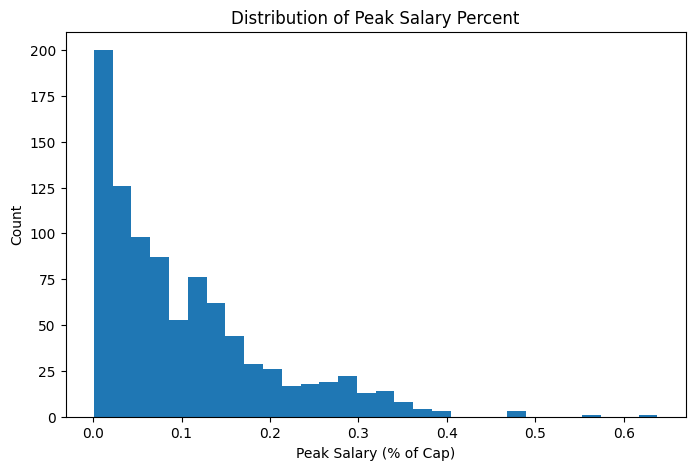

In [ ]:
mean_val = df["PeakSalaryPercent"].mean()
median_val = df["PeakSalaryPercent"].median()
plt.figure(figsize=(8,5))
plt.hist(df["PeakSalaryPercent"], bins=30)
plt.xlabel("Peak Salary (% of Cap)")
plt.ylabel("Count")
plt.title("Distribution of Peak Salary Percent")
plt.show()

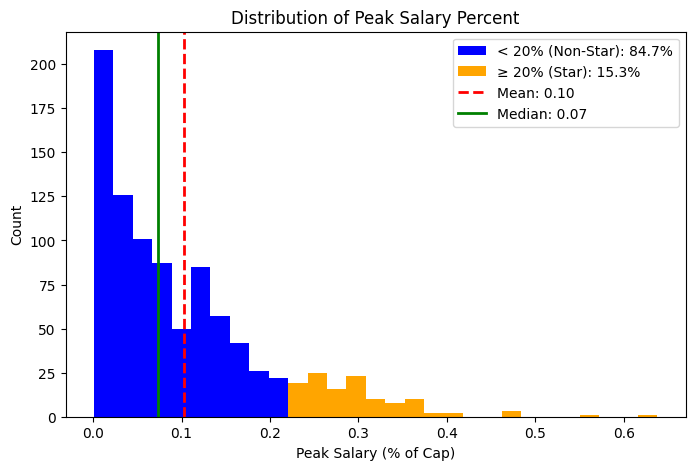

In [ ]:
# Data
data = df["PeakSalaryPercent"]

# Define bins
bins = np.linspace(data.min(), data.max(), 30)

# Compute proportions
below = (data < 0.20).mean()
above = (data >= 0.20).mean()

mean_val = df["PeakSalaryPercent"].mean()
median_val = df["PeakSalaryPercent"].median()

plt.figure(figsize=(8,5))

# Histogram
counts, bins, patches = plt.hist(data, bins=bins)

# Color bars
for i in range(len(patches)):
    if bins[i] < 0.20:
        patches[i].set_facecolor('blue')
    else:
        patches[i].set_facecolor('orange')

# Mean and median lines
mean_line = plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
median_line = plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

# Custom legend elements for histogram colors
legend_elements = [
    Patch(facecolor='blue', label=f"< 20% (Non-Star): {below:.1%}"),
    Patch(facecolor='orange', label=f"≥ 20% (Star): {above:.1%}"),
    mean_line,
    median_line
]

# Labels
plt.xlabel("Peak Salary (% of Cap)")
plt.ylabel("Count")
plt.title("Distribution of Peak Salary Percent")

plt.legend(handles=legend_elements)

plt.show()

In [ ]:
df["StarContract"].value_counts(normalize=True)

,proportion
StarContract,
0.0,0.849567
1.0,0.150433


In [ ]:
# --- STEP 1: Filter players who achieved a star contract ---
stars = df[df["StarContract"] == 1].copy()

# --- STEP 2: Compute average WS across first two seasons ---
stars["avg_WS_first2"] = stars[["WS_Y1", "WS_Y2"]].mean(axis=1)

# --- STEP 3: Sort by lowest WS (worst early performance) ---
worst_ws_stars = stars.sort_values("avg_WS_first2", ascending=True)

# --- STEP 4: Select columns to display ---
cols_to_show = [
    "Player",
    "DraftYear",
    "WS_Y1",
    "WS_Y2",
    "avg_WS_first2",
    "PeakSalaryPercent"
]

# --- STEP 5: View results ---
worst_ws_stars[cols_to_show].head(15).round(2)

,Player,DraftYear,WS_Y1,WS_Y2,avg_WS_first2,PeakSalaryPercent
184,D'Angelo Russell,2015,0.0,1.3,0.65,0.23
490,Julius Randle,2014,-0.1,1.6,0.75,0.20
920,Zach LaVine,2014,-0.7,2.6,0.95,0.28
434,Jermaine O'Neal,1996,0.8,1.2,1.00,0.40
119,CJ McCollum,2013,0.2,1.8,1.00,0.25
153,Chris Kaman,2003,0.0,2.1,1.05,0.20
369,JJ Redick,2006,1.7,0.5,1.10,0.23
22,Allan Houston,1993,-1.2,3.8,1.30,0.36
688,Otto Porter Jr.,2013,0.0,2.7,1.35,0.25
223,DeAndre Jordan,2008,1.3,1.5,1.40,0.21


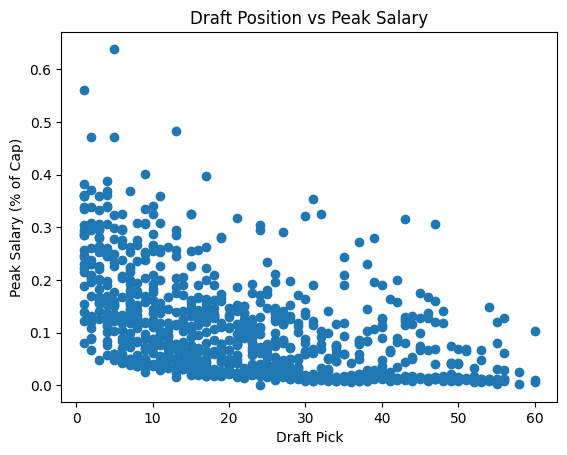

In [ ]:
plt.scatter(df["Pick"], df["PeakSalaryPercent"])
plt.xlabel("Draft Pick")
plt.ylabel("Peak Salary (% of Cap)")
plt.title("Draft Position vs Peak Salary")
plt.show()

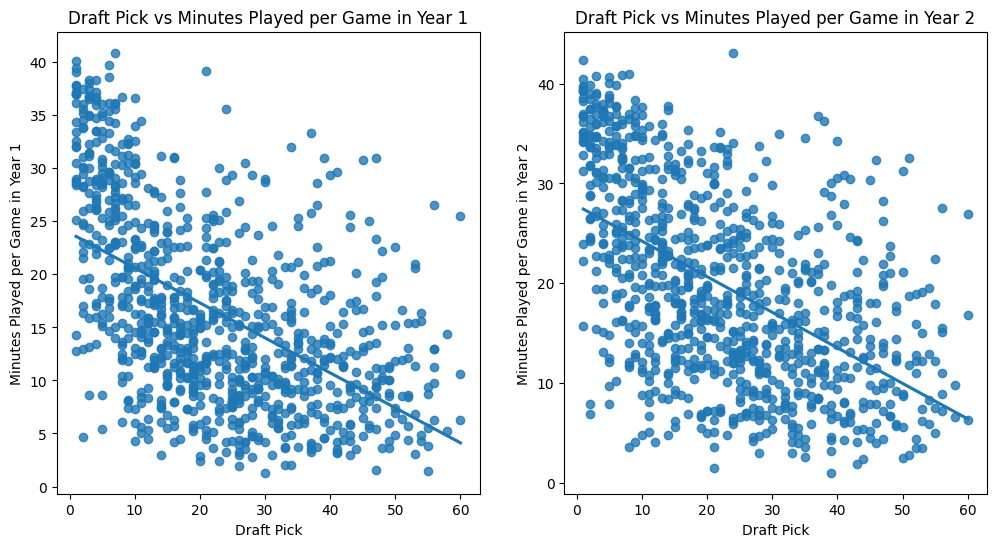

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(121)
sns.regplot(x = "Pick", y="MP_pg_Y1", data=df, ci=None)
plt.xlabel("Draft Pick")
plt.ylabel("Minutes Played per Game in Year 1")
plt.title("Draft Pick vs Minutes Played per Game in Year 1")

plt.subplot(122)
sns.regplot(x = "Pick", y="MP_pg_Y2", data=df, ci=None)
plt.xlabel("Draft Pick")
plt.ylabel("Minutes Played per Game in Year 2")
plt.title("Draft Pick vs Minutes Played per Game in Year 2")
plt.show()

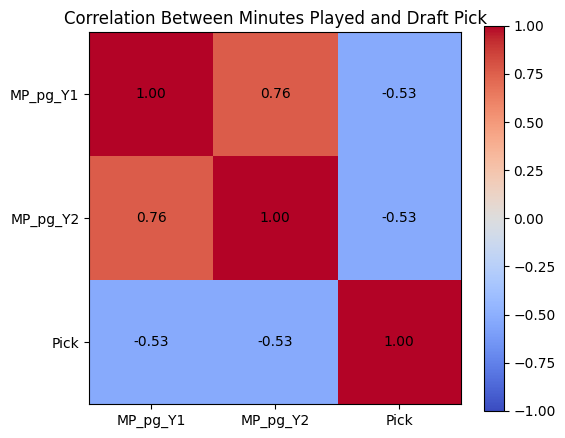

In [ ]:
corr = df[["MP_pg_Y1","MP_pg_Y2","Pick"]].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

# Axis labels
labels = corr.columns
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

# Add values
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

plt.title("Correlation Between Minutes Played and Draft Pick")
plt.colorbar()
plt.show()

In [ ]:
corr.loc["Pick", ["MP_pg_Y1", "MP_pg_Y2"]]

,Pick
MP_pg_Y1,-0.530424
MP_pg_Y2,-0.530090


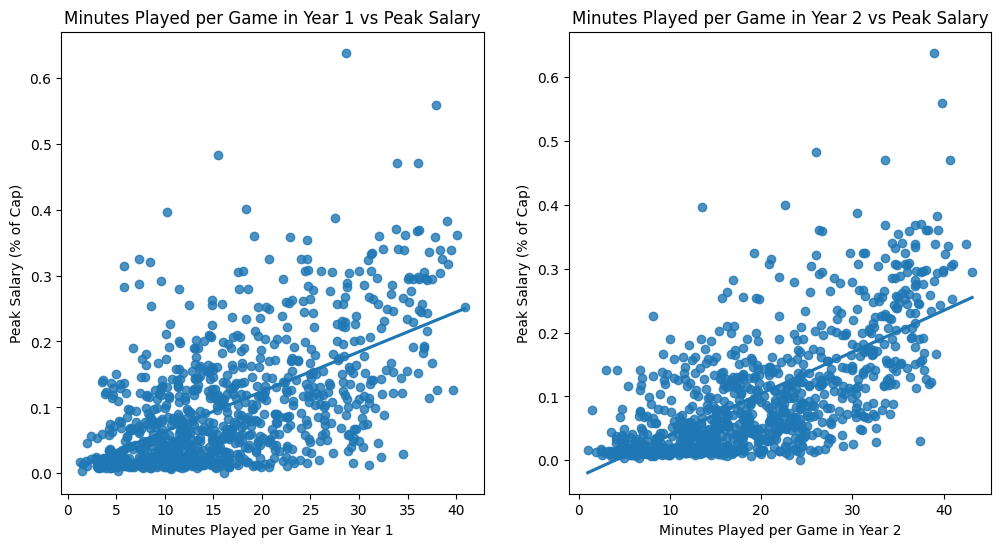

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(121)
sns.regplot(x = "MP_pg_Y1", y="PeakSalaryPercent", data=df, ci=None)
plt.xlabel("Minutes Played per Game in Year 1")
plt.ylabel("Peak Salary (% of Cap)")
plt.title("Minutes Played per Game in Year 1 vs Peak Salary")

plt.subplot(122)
sns.regplot(x = "MP_pg_Y2", y="PeakSalaryPercent", data=df, ci=None)
plt.xlabel("Minutes Played per Game in Year 2")
plt.ylabel("Peak Salary (% of Cap)")
plt.title("Minutes Played per Game in Year 2 vs Peak Salary")
plt.show()

In [ ]:
df[["MP_pg_Y1","MP_pg_Y2","PeakSalaryPercent"]].corr()

,MP_pg_Y1,MP_pg_Y2,PeakSalaryPercent
MP_pg_Y1,1.000000,0.758733,0.575763
MP_pg_Y2,0.758733,1.000000,0.672957
PeakSalaryPercent,0.575763,0.672957,1.000000


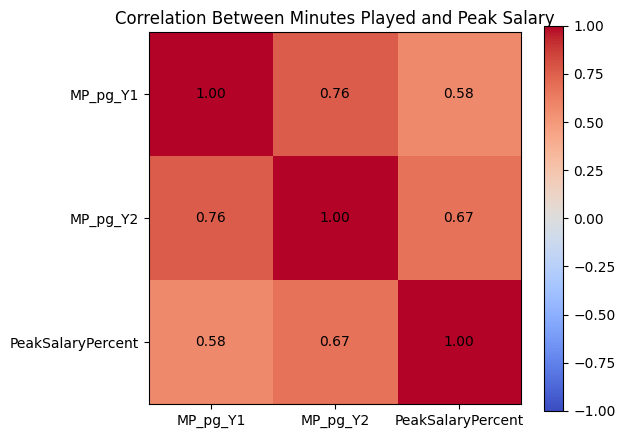

In [ ]:
corr = df[["MP_pg_Y1","MP_pg_Y2","PeakSalaryPercent"]].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

# Axis labels
labels = corr.columns
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

# Add values
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

plt.title("Correlation Between Minutes Played and Peak Salary")
plt.colorbar()
plt.show()

In [ ]:
cols = [col for col in df.columns
        if col not in ["Player", "PeakSalary", "StarContract", "DraftYear"]]

corr = df[cols].corr()["PeakSalaryPercent"].sort_values(ascending=False)

# View top and bottom
print(corr.head(35))
print(corr.tail(35))

PeakSalaryPercent    1.000000
PTS_Y2               0.711712
WS_Y2                0.699115
MP_pg_Y2             0.672957
VORP_Y2              0.643465
TOV_Y2               0.632023
PTS_Y1               0.601762
TRB_Y2               0.588154
MP_pg_Y1             0.575763
WS_Y1                0.572130
TRB_Y1               0.533092
TOV_Y1               0.532640
PER_Y2               0.526759
STL_Y2               0.515418
VORP_Y1              0.502043
AST_Y2               0.473918
BPM_Y2               0.469009
STL_Y1               0.452743
BLK_Y2               0.438856
VORP_jump_1_2        0.427467
BLK_Y1               0.420784
WS_jump_1_2          0.389037
AST_Y1               0.387189
WS/48_Y2             0.379854
PER_Y1               0.368088
MP_pg_jump_1_2       0.364526
PTS_jump_1_2         0.364526
BPM_Y1               0.356449
TS%_Y2               0.303121
USG%_Y2              0.299431
WS/48_Y1             0.262335
max_salary_year      0.260798
FG%_Y2               0.258224
eFG%_Y2   

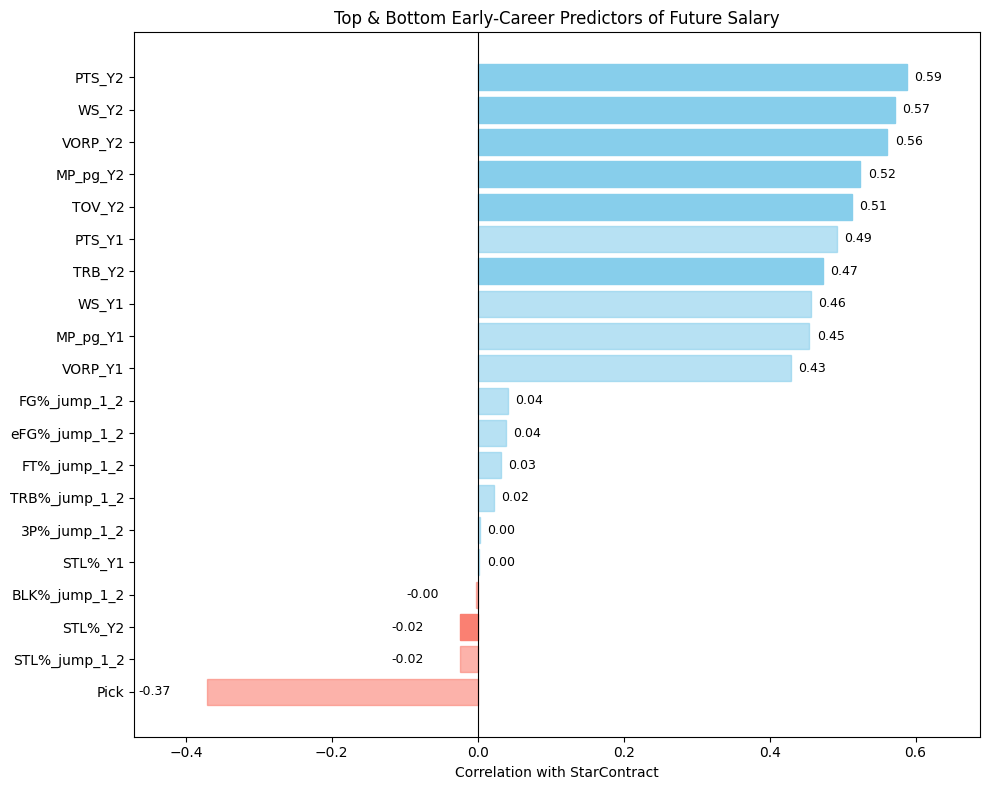

In [ ]:
# 1. Compute and clean correlations
corr = df.corr(numeric_only=True)["StarContract"].sort_values(ascending=False)
corr = corr.drop(["PeakSalaryPercent", "PeakSalary", "StarContract", "DraftYear"], errors='ignore')

# 2. Select Top 10 and Bottom 10
# We concatenate them; head(10) are the strongest positive, tail(10) are the strongest negative
top_bottom = pd.concat([corr.head(10), corr.tail(10)])

# Sort them again so the chart flows logically from highest to lowest
top_bottom = top_bottom.sort_values(ascending=True)

plt.figure(figsize=(10, 8))

# 3. Create the bars
bars = plt.barh(top_bottom.index, top_bottom.values)

# 4. Styling: Highlighting Year 2 and differentiating Pos/Neg
for bar, name, val in zip(bars, top_bottom.index, top_bottom.values):
    # Set color based on positive/negative correlation
    if val > 0:
        bar.set_color('skyblue')
    else:
        bar.set_color('salmon')

    # Adjust alpha based on your "_Y2" logic
    if "_Y2" in name:
        bar.set_alpha(1.0)
    else:
        bar.set_alpha(0.6)

# Labels and formatting
plt.axvline(0, color='black', linewidth=0.8) # Add a vertical line at 0
plt.xlabel("Correlation with StarContract")
plt.title("Top & Bottom Early-Career Predictors of Future Salary")

# 5. Dynamic value labels (places text left of negative bars and right of positive)
for i, v in enumerate(top_bottom.values):
    offset = 0.01 if v >= 0 else -0.05
    plt.text(v + offset, i, f"{v:.2f}", va='center',
             ha='left' if v >= 0 else 'right', fontsize=9)

# Expand x-axis slightly to fit the labels
plt.xlim(top_bottom.min() - 0.1, top_bottom.max() + 0.1)

plt.tight_layout()
plt.show()

In [ ]:
corr = df.corr(numeric_only=True)["StarContract"]

# Group columns
y1_cols = [c for c in corr.index if "_Y1" in c]
y2_cols = [c for c in corr.index if "_Y2" in c]
jump_cols = [c for c in corr.index if "_jump_1_2" in c]

# Compute average correlation
summary = pd.DataFrame({
    "Group": ["Year 1", "Year 2", "Improvement"],
    "Avg Correlation": [
        corr[y1_cols].mean(),
        corr[y2_cols].mean(),
        corr[jump_cols].mean()
    ]
})

print("\n=== AVERAGE CORRELATION BY GROUP ===")
print(summary)

# Also show top 5 from each group
print("\n=== TOP YEAR 1 FEATURES ===")
print(corr[y1_cols].sort_values(ascending=False).head(5))

print("\n=== TOP YEAR 2 FEATURES ===")
print(corr[y2_cols].sort_values(ascending=False).head(5))

print("\n=== TOP IMPROVEMENT FEATURES ===")
print(corr[jump_cols].sort_values(ascending=False).head(5))


=== AVERAGE CORRELATION BY GROUP ===
         Group  Avg Correlation
0       Year 1         0.242994
1       Year 2         0.306457
2  Improvement         0.128331

=== TOP YEAR 1 FEATURES ===
PTS_Y1      0.492173
WS_Y1       0.456429
MP_pg_Y1    0.454509
VORP_Y1     0.429156
TOV_Y1      0.428111
Name: StarContract, dtype: float64

=== TOP YEAR 2 FEATURES ===
PTS_Y2      0.588217
WS_Y2       0.571970
VORP_Y2     0.561423
MP_pg_Y2    0.524295
TOV_Y2      0.512295
Name: StarContract, dtype: float64

=== TOP IMPROVEMENT FEATURES ===
VORP_jump_1_2     0.381514
WS_jump_1_2       0.329804
MP_pg_jump_1_2    0.308718
PTS_jump_1_2      0.308718
AST_jump_1_2      0.219998
Name: StarContract, dtype: float64


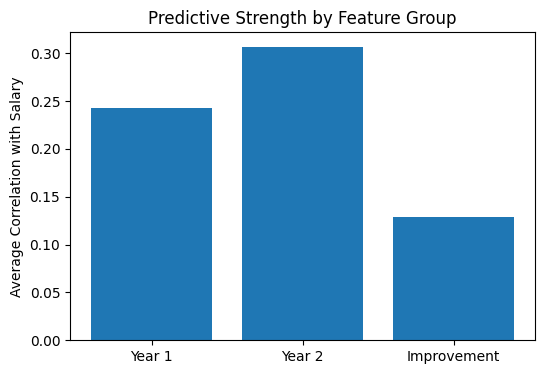

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(summary["Group"], summary["Avg Correlation"])
plt.title("Predictive Strength by Feature Group")
plt.ylabel("Average Correlation with Salary")
plt.show()

In [ ]:
print("Year 1 features:", len(y1_cols))
print("Year 2 features:", len(y2_cols))
print("Improvement features:", len(jump_cols))

Year 1 features: 22
Year 2 features: 22
Improvement features: 22


In [ ]:
top20 = corr.sort_values(ascending=False).head(20)

print("\nTop 20 features:")
print(top20)


Top 20 features:
StarContract         1.000000
PeakSalaryPercent    0.809009
PeakSalary           0.726736
PTS_Y2               0.588217
WS_Y2                0.571970
VORP_Y2              0.561423
MP_pg_Y2             0.524295
TOV_Y2               0.512295
PTS_Y1               0.492173
TRB_Y2               0.472836
WS_Y1                0.456429
MP_pg_Y1             0.454509
VORP_Y1              0.429156
TOV_Y1               0.428111
TRB_Y1               0.423805
PER_Y2               0.407436
AST_Y2               0.397996
STL_Y2               0.387170
VORP_jump_1_2        0.381514
STL_Y1               0.341396
Name: StarContract, dtype: float64


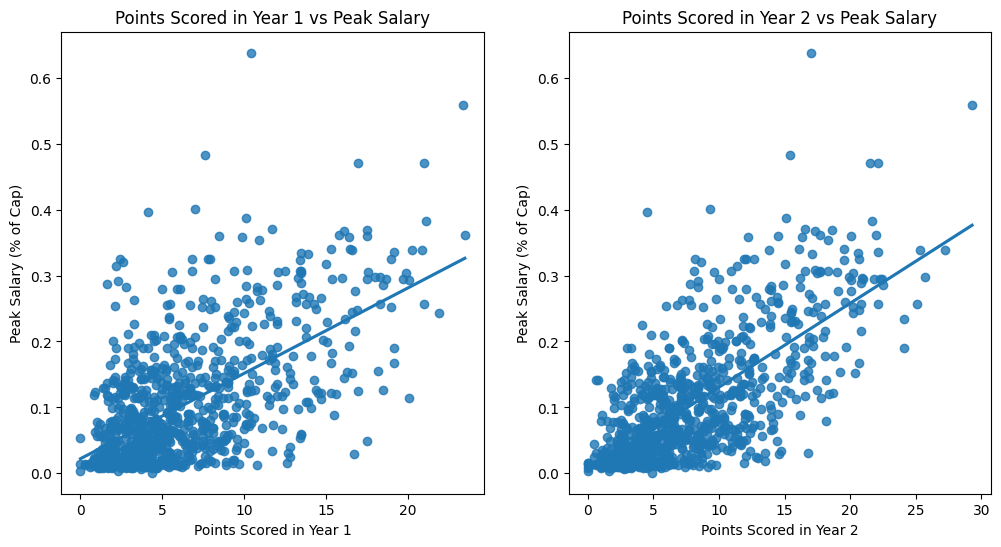

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(121)
sns.regplot(x = "PTS_Y1", y="PeakSalaryPercent", data=df, ci=None)
plt.xlabel("Points Scored in Year 1")
plt.ylabel("Peak Salary (% of Cap)")
plt.title("Points Scored in Year 1 vs Peak Salary")

plt.subplot(122)
sns.regplot(x = "PTS_Y2", y="PeakSalaryPercent", data=df, ci=None)
plt.xlabel("Points Scored in Year 2")
plt.ylabel("Peak Salary (% of Cap)")
plt.title("Points Scored in Year 2 vs Peak Salary")
plt.show()

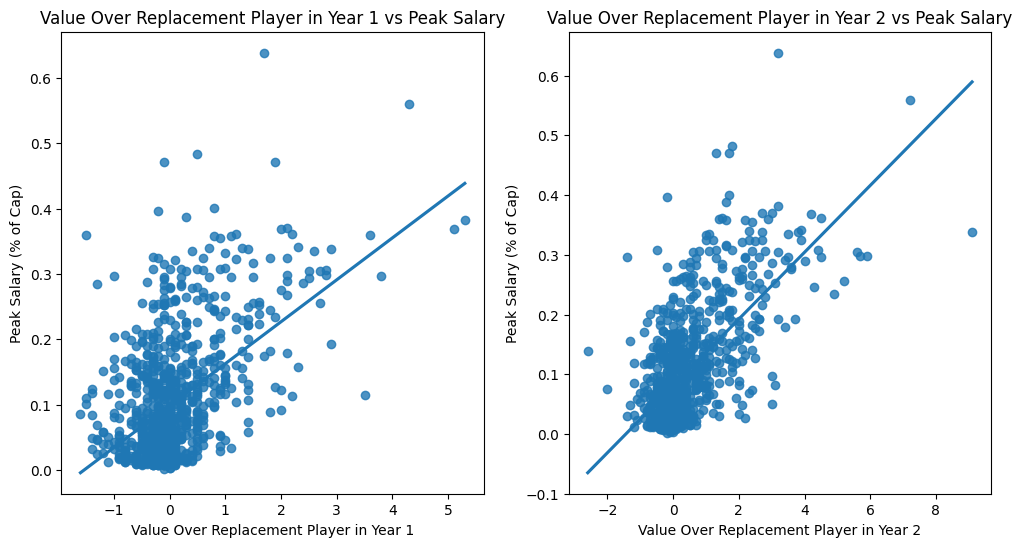

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(121)
sns.regplot(x = "VORP_Y1", y="PeakSalaryPercent", data=df, ci=None)
plt.xlabel("Value Over Replacement Player in Year 1")
plt.ylabel("Peak Salary (% of Cap)")
plt.title("Value Over Replacement Player in Year 1 vs Peak Salary")

plt.subplot(122)
sns.regplot(x = "VORP_Y2", y="PeakSalaryPercent", data=df, ci=None)
plt.xlabel("Value Over Replacement Player in Year 2")
plt.ylabel("Peak Salary (% of Cap)")
plt.title("Value Over Replacement Player in Year 2 vs Peak Salary")
plt.show()

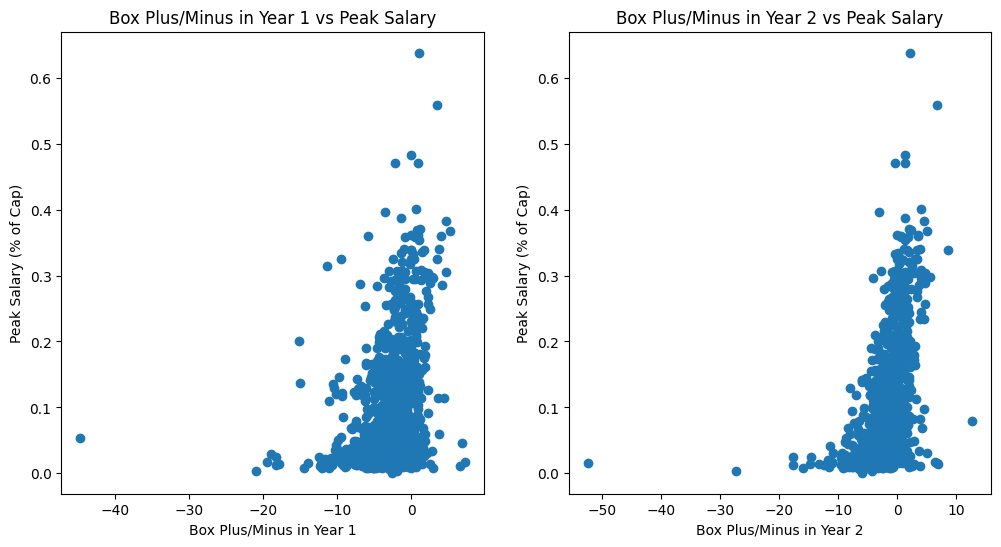

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.scatter(df["BPM_Y1"], df["PeakSalaryPercent"])
plt.xlabel("Box Plus/Minus in Year 1")
plt.ylabel("Peak Salary (% of Cap)")
plt.title("Box Plus/Minus in Year 1 vs Peak Salary")

plt.subplot(122)
plt.scatter(df["BPM_Y2"], df["PeakSalaryPercent"])
plt.xlabel("Box Plus/Minus in Year 2")
plt.ylabel("Peak Salary (% of Cap)")
plt.title("Box Plus/Minus in Year 2 vs Peak Salary")
plt.show()

#**Model Building**

# OLS / Lasso / Ridge

In [ ]:
# 1) Define features and target (no encoding yet)
X_raw = df.drop(["StarContract", "Player", "PeakSalary", "PeakSalaryPercent"], axis=1)
y = df["StarContract"]

# 2) Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# 3) One-hot encode AFTER the split, then align columns
X_train = pd.get_dummies(X_train_raw, drop_first=True)
X_test  = pd.get_dummies(X_test_raw,  drop_first=True)

X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

# 4) Fit multiple linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# 5) Predictions
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# 6) Evaluate fit
r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("R^2 (train):", r2_train)
print("R^2 (test): ", r2_test)
print("RMSE (train):", rmse_train)
print("RMSE (test): ", rmse_test)

# 7) Coefficients (sorted by absolute magnitude for readability)
coef_series = pd.Series(model.coef_, index=X_train.columns).sort_values(key=np.abs, ascending=False)
print("\nIntercept:", model.intercept_)
print("\nCoefficients:\n", coef_series)

R^2 (train): 0.5236108305760794
R^2 (test):  0.2611109002910148
RMSE (train): 0.24567341713306465
RMSE (test):  0.31252099591508403

Intercept: -4.977075006468434

Coefficients:
 TS%_Y1           0.919643
TS%_jump_1_2    -0.613162
eFG%_Y1         -0.538857
eFG%_jump_1_2    0.489666
TS%_Y2           0.306481
                   ...   
AST%_Y1         -0.002230
AST%_jump_1_2   -0.001786
BLK%_Y1         -0.001742
Pick            -0.001273
PER_Y2           0.000097
Length: 69, dtype: float64


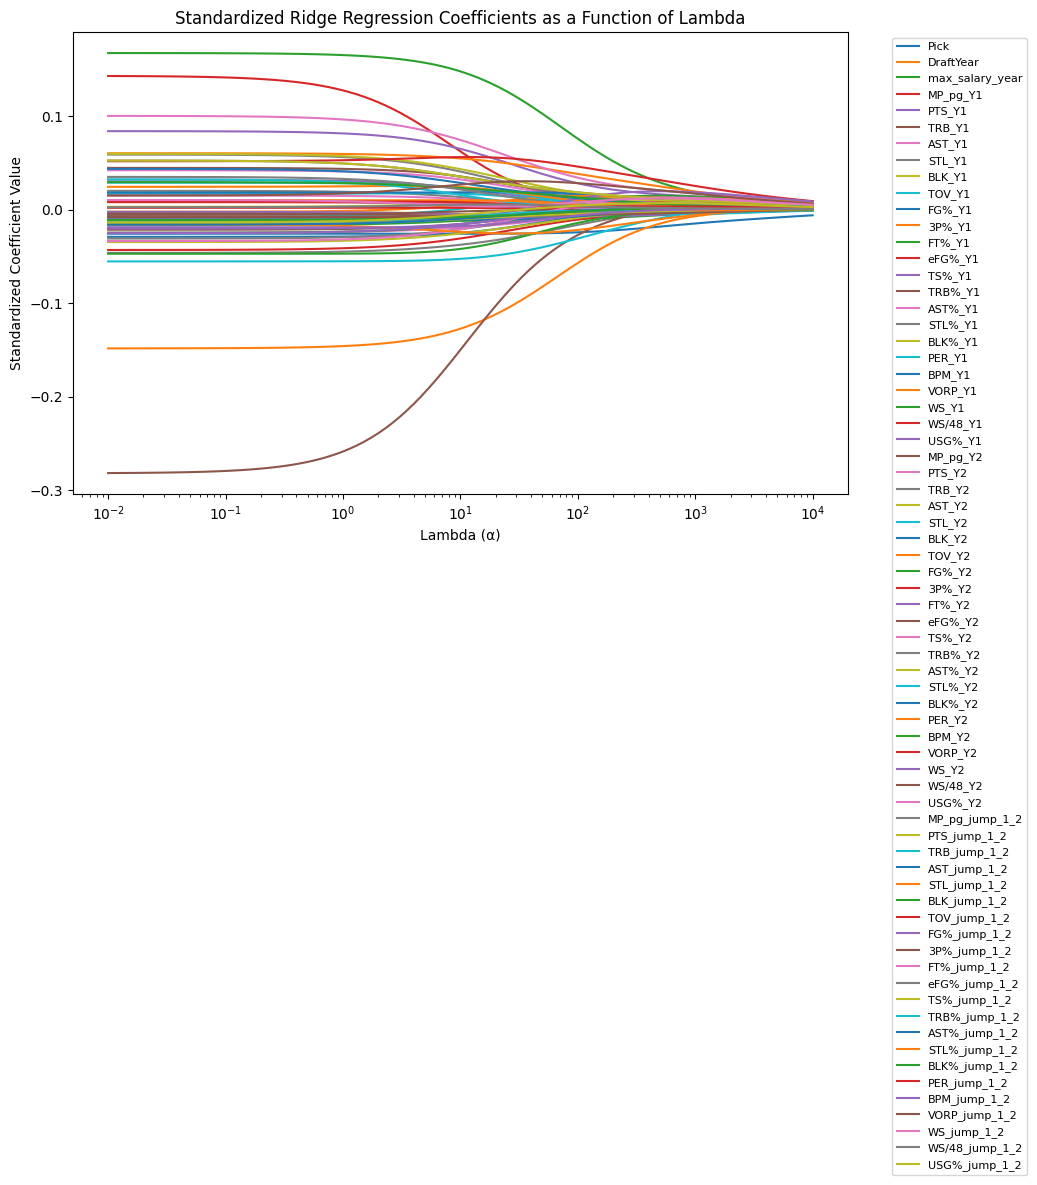

In [ ]:
X_raw = df.drop(["StarContract", "Player", "PeakSalary", "PeakSalaryPercent"], axis=1)
y = df["StarContract"]

# 2) One-hot encode categorical variables
X = pd.get_dummies(X_raw, drop_first=True)

# 3) Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-2, 4, 100)  # λ from 0.01 to 10,000
coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_scaled, y)
    coefs.append(ridge.coef_)

coefs = np.array(coefs)

# 5) Plot coefficient paths
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Standardized Coefficient Value")
plt.title("Standardized Ridge Regression Coefficients as a Function of Lambda")
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
#plt.tight_layout()
plt.show()

Best lambda (alpha): 24.7708


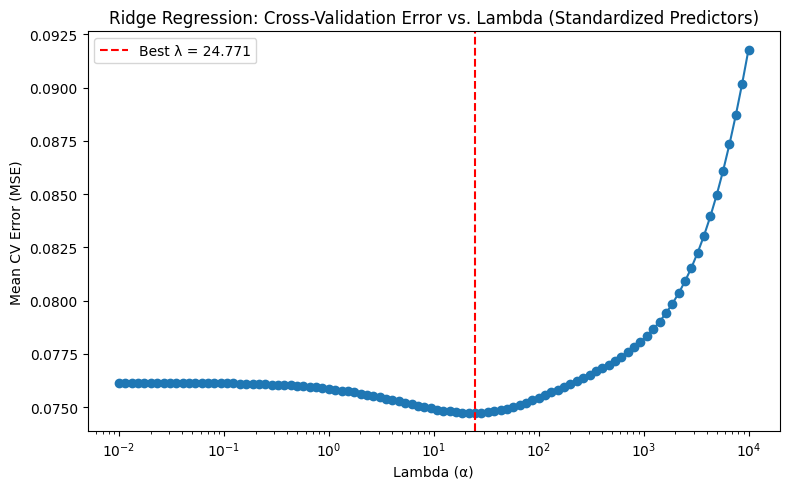

In [ ]:
alphas = np.logspace(-2, 4, 100)

# 2) Create a 5-fold cross-validation setup
#    Each fold uses 80% of the data for training and 20% for validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 3) Set up GridSearchCV to test each alpha value
#    - estimator: Ridge regression
#    - scoring: negative mean squared error (smaller = better)
#    - cv: the 5-fold splitter defined above
#    - return_train_score: True lets us inspect both train and test errors
gs = GridSearchCV(
    estimator=Ridge(),
    param_grid={"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=cv,
    return_train_score=True,
)

# 4) Fit the grid search on the standardized predictors
#    Each model is trained and validated internally across the 5 folds
gs.fit(X_scaled, y)

# 5) Identify the best alpha (lambda) value that minimizes CV error
best_alpha = gs.best_params_["alpha"]
print(f"Best lambda (alpha): {best_alpha:.4f}")

# 6) Extract the mean cross-validation MSE for plotting
mean_cv_mse = -gs.cv_results_["mean_test_score"]  # convert from negative MSE

# 7) Plot cross-validation error vs. lambda
plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse, marker="o")
plt.axvline(best_alpha, linestyle="--", color="red", label=f"Best λ = {best_alpha:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Ridge Regression: Cross-Validation Error vs. Lambda (Standardized Predictors)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 1) Define features and target
X_raw = df.drop(["StarContract", "Player", "PeakSalary", "PeakSalaryPercent"], axis=1)
y = df["StarContract"]

# 2) One-hot encode categorical variables
X = pd.get_dummies(X_raw, drop_first=True)

# 3) Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4) Fit Lasso models for a range of lambda (alpha) values
#    Lasso typically benefits from a slightly smaller alpha range than Ridge.
alphas = np.logspace(-3, 2, 100)  # λ from 0.001 to 100
coefs = []

X_scaled

array([[ 0.65281502, -0.46985475, -1.09633199, ..., -0.59036931,
        -0.37863911,  1.41965154],
       [ 2.02294807,  0.78934993,  0.21196035, ..., -0.97020704,
        -0.74986511,  0.067886  ],
       [ 0.2417751 ,  0.50952666,  0.47361882, ...,  0.71193147,
        -0.5223395 ,  0.32875303],
       ...,
       [-0.23777147, -0.32994312,  0.47361882, ...,  1.85144466,
         0.73503888, -0.57242399],
       [ 1.33788154, -0.05011986,  0.34278959, ...,  0.92898161,
         0.69911378, -0.02697474],
       [-0.37478477, -0.05011986, -0.44218582, ...,  0.44061881,
         1.75291662,  0.11531637]])

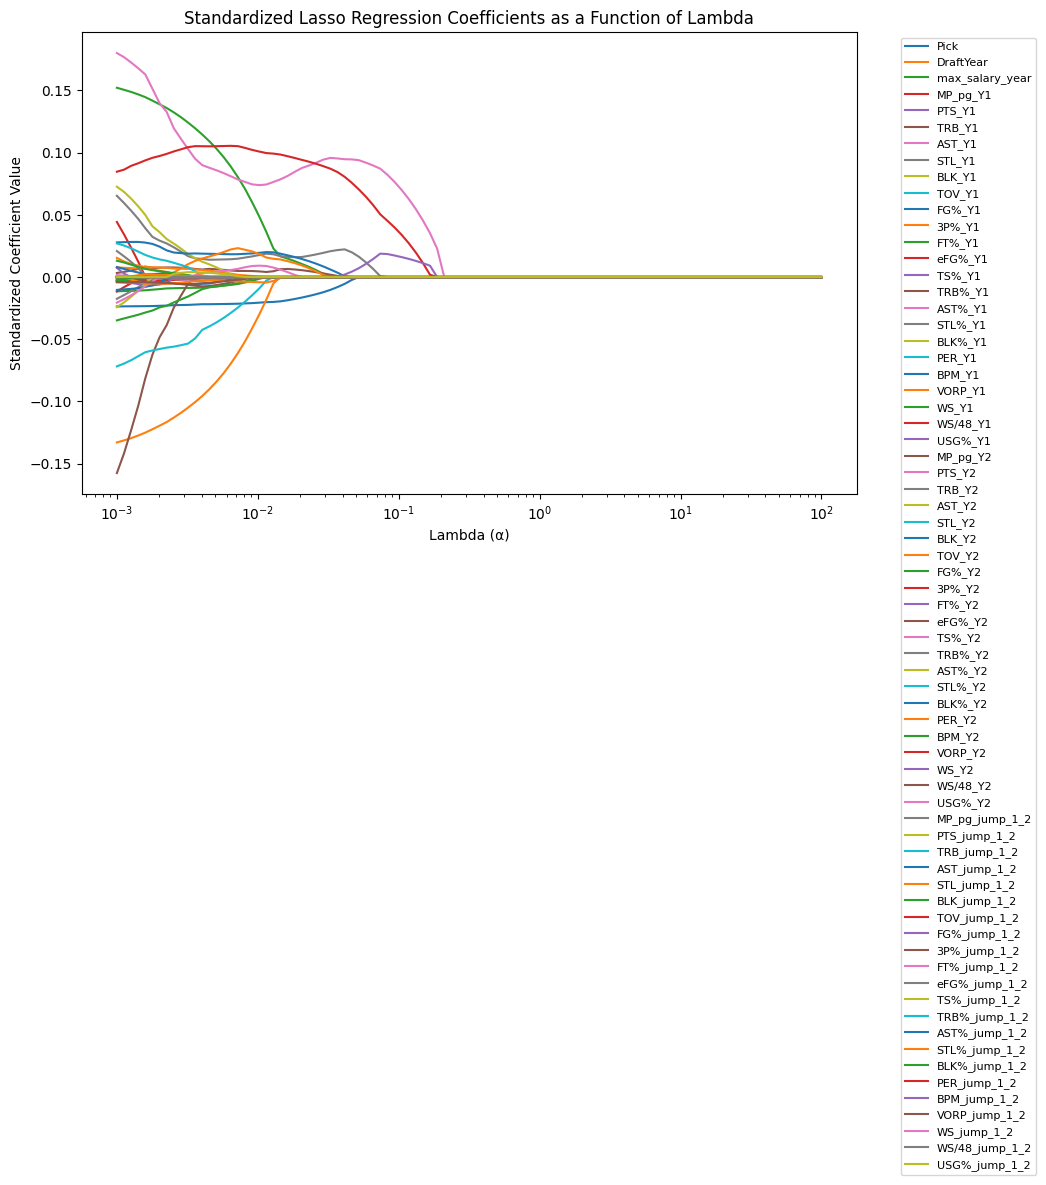

In [ ]:
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

# 5) Plot coefficient paths
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Standardized Coefficient Value")
plt.title("Standardized Lasso Regression Coefficients as a Function of Lambda")
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
#plt.tight_layout()
plt.show()

Best lambda (alpha) for Lasso: 0.0014


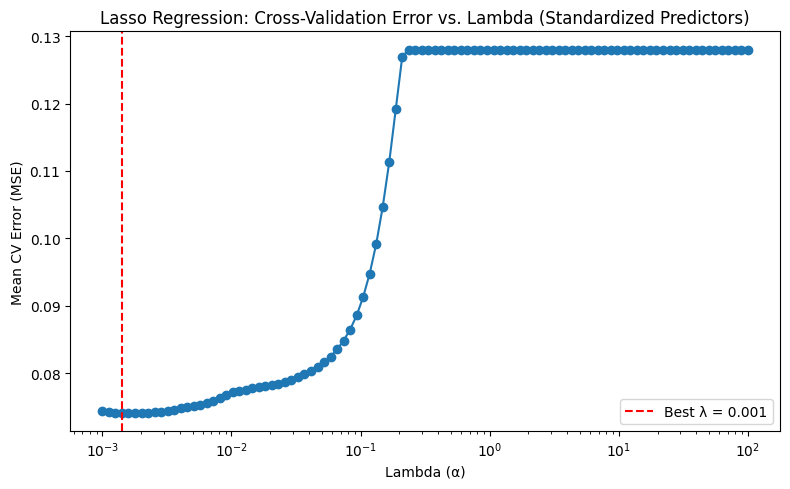

In [ ]:
## Lasso Regression with Cross-Validation (using GridSearchCV)

# 1) Define the range of lambda (alpha) values to test
#    Lasso is more sensitive to alpha, so we use a smaller range.
alphas = np.logspace(-3, 2, 100)  # 0.001 → 100

# 2) Create a 5-fold cross-validation setup
#    Each fold uses 80% of the data for training and 20% for validation.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 3) Set up GridSearchCV to test each alpha value
#    - estimator: Lasso regression (with a higher max_iter to ensure convergence)
#    - scoring: negative mean squared error (smaller = better)
#    - cv: the 5-fold splitter defined above
#    - return_train_score: True lets us inspect both train and test errors
gs_lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid={"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=cv,
    return_train_score=True,
)

# 4) Fit the grid search on the standardized predictors
#    Each model is trained and validated internally across the 5 folds.
gs_lasso.fit(X_scaled, y)

# 5) Identify the best alpha (lambda) value that minimizes CV error
best_alpha_lasso = gs_lasso.best_params_["alpha"]
print(f"Best lambda (alpha) for Lasso: {best_alpha_lasso:.4f}")

# 6) Extract the mean cross-validation MSE for plotting
mean_cv_mse_lasso = -gs_lasso.cv_results_["mean_test_score"]  # convert from negative MSE

# 7) Plot cross-validation error vs. lambda
plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse_lasso, marker="o")
plt.axvline(best_alpha_lasso, linestyle="--", color="red", label=f"Best λ = {best_alpha_lasso:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Lasso Regression: Cross-Validation Error vs. Lambda (Standardized Predictors)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
lasso_best = Lasso(alpha=best_alpha_lasso)
lasso_best.fit(X_scaled, y)

lasso_coefs = pd.Series(lasso_best.coef_, index=X.columns)
lasso_coefs = lasso_coefs.reindex(lasso_coefs.abs().sort_values(ascending=False).index)
lasso_coefs.head(20)

,0
PTS_Y2,0.167886
max_salary_year,0.146855
DraftYear,-0.127408
MP_pg_Y2,-0.103471
VORP_Y2,0.091494
STL_Y2,-0.063620
AST_Y2,0.056863
TRB_Y2,0.046768
BPM_Y2,-0.030304
BLK_Y2,0.028237


In [ ]:
## Compare OLS, Ridge, and Lasso Coefficients (using best λ from CV)

# 1) Fit OLS (no regularization)
ols = LinearRegression()
ols.fit(X_scaled, y)
ols_coefs = pd.Series(ols.coef_, index=X.columns)

# 2) Fit Ridge with best λ from CV
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_scaled, y)
ridge_coefs = pd.Series(ridge_best.coef_, index=X.columns)

# 3) Fit Lasso with best λ from CV
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_best.fit(X_scaled, y)
lasso_coefs = pd.Series(lasso_best.coef_, index=X.columns)

# 4) Combine into one DataFrame for comparison
coef_compare = pd.DataFrame({
    "OLS": ols_coefs,
    f"Ridge (λ={best_alpha:.3f})": ridge_coefs,
    f"Lasso (λ={best_alpha_lasso:.3f})": lasso_coefs
})

# 5) Sort by absolute OLS coefficient for readability
coef_compare = coef_compare.reindex(ols_coefs.abs().sort_values(ascending=False).index)

# 6) Display
print(coef_compare.head(20))

                      OLS  Ridge (λ=24.771)  Lasso (λ=0.001)
MP_pg_Y2        -0.281990         -0.089272        -0.103471
max_salary_year  0.167614          0.126649         0.146855
DraftYear       -0.148366         -0.105847        -0.127408
MP_pg_Y1         0.143211          0.032957         0.012396
PTS_Y2           0.100408          0.057942         0.167886
PTS_Y1           0.084065          0.050395         0.000000
VORP_Y1          0.060426          0.049748         0.009233
AST_Y2           0.059842          0.033071         0.056863
TRB_Y2           0.059026          0.029312         0.046768
STL_Y2          -0.055296         -0.047347        -0.063620
PTS_jump_1_2     0.052624          0.027656         0.000000
MP_pg_jump_1_2   0.052624          0.027656         0.007026
VORP_Y2          0.051837          0.055114         0.091494
BPM_Y2          -0.047108         -0.032888        -0.030304
STL_Y1          -0.046157         -0.030706        -0.000000
TRB_Y1           0.04474

In [ ]:
ols = LinearRegression().fit(X_scaled, y)
ridge = Ridge(alpha=best_alpha).fit(X_scaled, y)
lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000).fit(X_scaled, y)

# 2) Make predictions
y_pred_ols = ols.predict(X_scaled)
y_pred_ridge = ridge.predict(X_scaled)
y_pred_lasso = lasso.predict(X_scaled)

# 3) Compute R² and RMSE for each model
results = {
    "Model": ["OLS", f"Ridge (λ={best_alpha:.3f})", f"Lasso (λ={best_alpha_lasso:.3f})"],
    "R²": [
        r2_score(y, y_pred_ols),
        r2_score(y, y_pred_ridge),
        r2_score(y, y_pred_lasso)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y, y_pred_ols)),
        np.sqrt(mean_squared_error(y, y_pred_ridge)),
        np.sqrt(mean_squared_error(y, y_pred_lasso))
    ]
}

# 4) Create DataFrame and display
fit_compare = pd.DataFrame(results)
print(fit_compare.to_string(index=False, float_format="%.4f"))

           Model     R²   RMSE
             OLS 0.4840 0.2568
Ridge (λ=24.771) 0.4748 0.2591
 Lasso (λ=0.001) 0.4736 0.2594


In [ ]:
from sklearn.model_selection import train_test_split

# Define features and target
X_raw = df.drop(["StarContract", "Player", "PeakSalary", "PeakSalaryPercent"], axis=1)
y = df["StarContract"]

# Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# One-hot encode AFTER the split, then align columns
X_train = pd.get_dummies(X_train_raw, drop_first=True)
X_test  = pd.get_dummies(X_test_raw,  drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (739, 69)
X_test shape: (185, 69)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# PCA

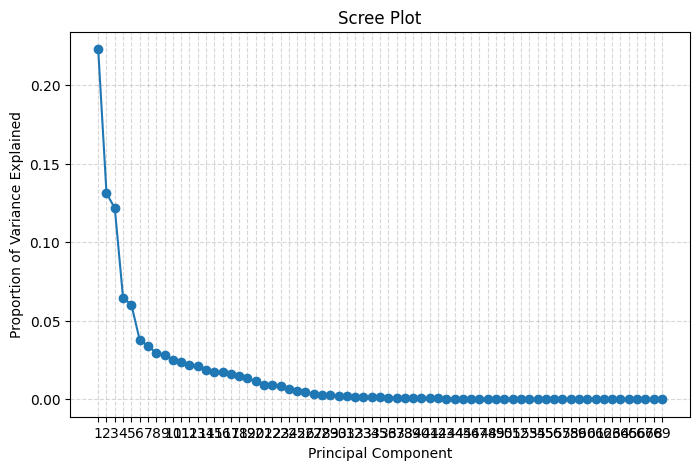

In [ ]:
from sklearn.decomposition import PCA

# Fit PCA on standardized training predictors
pca = PCA()
pca.fit(X_train_scaled)

# Explained variance ratios
explained = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(explained) + 1), explained, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.title("Scree Plot")
plt.xticks(np.arange(1, len(explained) + 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

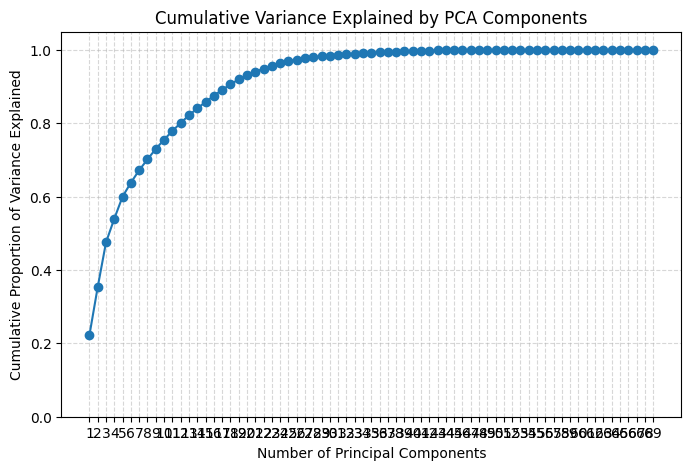

In [ ]:
# Cumulative Variance Explained Plot

# Explained variance ratios (already computed by pca.fit)
explained = pca.explained_variance_ratio_

# Cumulative sum
cumulative = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cumulative) + 1), cumulative, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Proportion of Variance Explained")
plt.title("Cumulative Variance Explained by PCA Components")
plt.xticks(np.arange(1, len(cumulative) + 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, 1.05)
plt.show()


In [ ]:
# PCA loadings (also called component weightings)
# Shape: (n_components, n_original_features)
loadings = pd.DataFrame(
    pca.components_.T,          # transpose so rows = original variables
    columns=[f"PC{i+1}" for i in range(len(pca.components_))],
    index=X_train.columns
)

PC1 = loadings["PC1"]
loadings = loadings.reindex(PC1.abs().sort_values(ascending=False).index)

# Display the first few principal components' loadings
loadings.iloc[:, :5]    # show loadings for PC1–PC5

,PC1,PC2,PC3,PC4,PC5
PTS_Y2,0.229216,-0.018047,-0.040499,0.060849,-0.102516
MP_pg_Y2,0.225056,-0.014531,-0.030030,0.075626,-0.103059
WS_Y2,0.219896,0.020749,0.030801,0.045265,-0.035816
TOV_Y2,0.207324,-0.040613,-0.083690,0.057018,-0.151712
PER_Y2,0.205873,0.083920,0.080322,-0.073147,0.108589
...,...,...,...,...,...
TRB%_Y2,0.009227,0.014956,0.279058,-0.019816,-0.127832
STL%_jump_1_2,-0.007251,-0.005599,0.000992,0.115957,-0.059684
BLK%_Y2,0.007201,0.013774,0.255740,-0.030878,-0.144475
BLK%_jump_1_2,-0.005398,0.029263,0.011225,-0.014802,-0.008250


X_train_pca shape: (739, 69)
X_test_pca shape:  (185, 69)


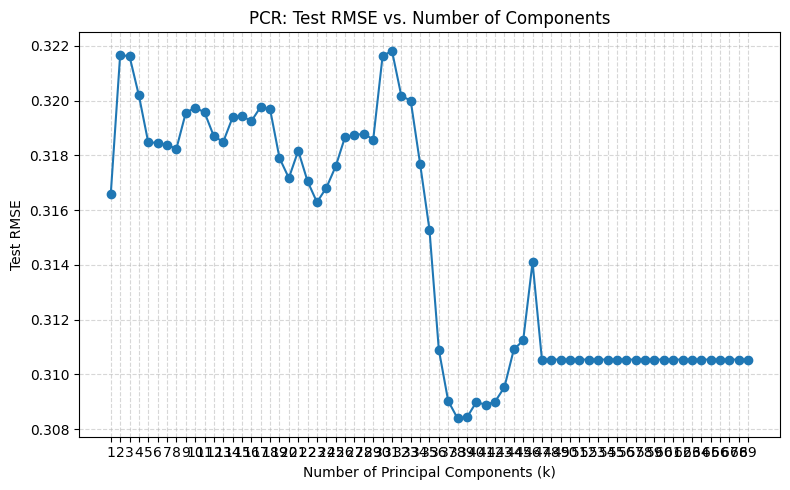

In [ ]:
# 1) Transform standardized predictors into principal component scores
X_train_pca = pca.transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("X_train_pca shape:", X_train_pca.shape)
print("X_test_pca shape: ", X_test_pca.shape)

# 2) For k = 1, 2, ..., p, fit PCR and record performance
n_components = X_train_pca.shape[1]

rmse_train_list = []
rmse_test_list  = []
r2_train_list   = []
r2_test_list    = []

k_values = range(1, n_components + 1)

for k in k_values:
    # Use the first k principal components
    X_train_k = X_train_pca[:, :k]
    X_test_k  = X_test_pca[:, :k]

    # Fit linear regression on these k components
    pcr_model = LinearRegression()
    pcr_model.fit(X_train_k, y_train)

    # Predictions
    y_train_pred = pcr_model.predict(X_train_k)
    y_test_pred  = pcr_model.predict(X_test_k)

    # Metrics
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2_train   = r2_score(y_train, y_train_pred)
    r2_test    = r2_score(y_test, y_test_pred)

    rmse_train_list.append(rmse_train)
    rmse_test_list.append(rmse_test)
    r2_train_list.append(r2_train)
    r2_test_list.append(r2_test)

# 3) Plot test RMSE vs. number of components
plt.figure(figsize=(8, 5))
plt.plot(k_values, rmse_test_list, marker="o")
plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Test RMSE")
plt.title("PCR: Test RMSE vs. Number of Components")
plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Decision Trees

In [ ]:
### 1. Identify the best PCR model (k with minimum test RMSE)
best_k = np.argmin(rmse_test_list) + 1   # +1 because index 0 corresponds to k=1
print(f"Best number of components for PCR: k = {best_k}")

### 2. Fit the final PCR model using k* components
X_train_k = X_train_pca[:, :6]
X_test_k  = X_test_pca[:, :6]
pca = PCA()
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)
X_k  = X_pca[:, :best_k]

pcr_final = LogisticRegression()
pcr_final.fit(X_k, y)

y_test_pred_pcr = pcr_final.predict(X_k)
rmse_test_pcr = np.sqrt(mean_squared_error(y, y_test_pred_pcr))
r2_test_pcr   = r2_score(y, y_test_pred_pcr)

### 3. Fit/reuse OLS on scaled features
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

y_test_pred_ols = ols.predict(X_test_scaled)
rmse_test_ols = np.sqrt(mean_squared_error(y_test, y_test_pred_ols))
r2_test_ols   = r2_score(y_test, y_test_pred_ols)

### 4. Fit/reuse Ridge with best alpha from earlier CV
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train_scaled, y_train)

y_test_pred_ridge = ridge_best.predict(X_test_scaled)
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
r2_test_ridge   = r2_score(y_test, y_test_pred_ridge)

### 5. Combine results into a comparison table
results = pd.DataFrame({
    "Model": ["OLS", f"Ridge (λ={best_alpha:.3f})", f"PCR (k={best_k})"],
    "Test RMSE": [rmse_test_ols, rmse_test_ridge, rmse_test_pcr],
    "Test R^2":  [r2_test_ols,  r2_test_ridge,  r2_test_pcr]
})

print("\nModel Comparison on Test Set:\n")
print(results.to_string(index=False, float_format="%.4f"))

Best number of components for PCR: k = 38

Model Comparison on Test Set:

           Model  Test RMSE  Test R^2
             OLS     0.3105    0.2704
Ridge (λ=24.771)     0.3096    0.2746
      PCR (k=38)     0.2590    0.4750


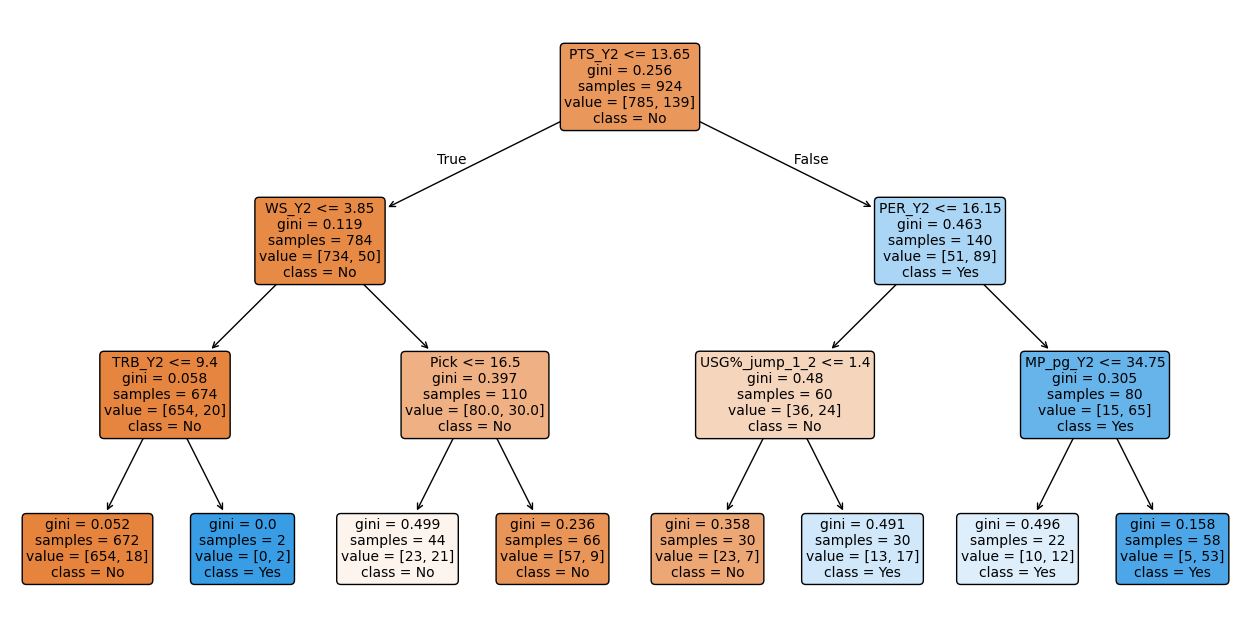

In [ ]:
# 1) Select four intuitive predictors (DataFrame, not list)
X_raw = df.drop(["StarContract", "Player", "PeakSalary", "PeakSalaryPercent"], axis=1)

# 2) One-hot encode categoricals; drop first level for each
X = pd.get_dummies(X_raw, drop_first=True)

# 3) Target: AHD (Yes/No) -> 1/0
y = df["StarContract"]

# 4) Fit a small, readable tree
clf = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
clf.fit(X, y)

# 5) Plot the tree
plt.figure(figsize=(16, 8))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

Selected alpha (via 5-fold CV): 0.0117034  |  CV Error: 0.1056
Test Accuracy: 0.8865
Confusion matrix (rows=true, cols=pred):
[[151   6]
 [ 15  13]]
Features used in final pruned tree: ['PTS_Y2', 'PER_Y2']


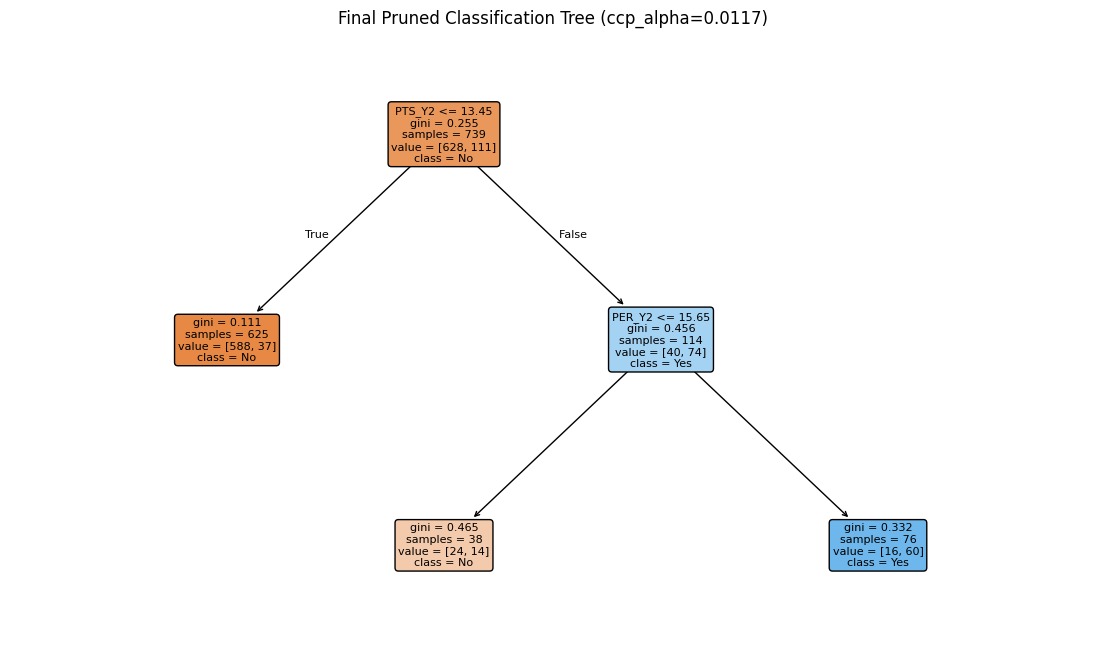

In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=8, stratify=y
)

# -----------------------------------------------------------
# 1) Grow a large tree and get pruning path (candidate alphas)
# -----------------------------------------------------------
big_tree = DecisionTreeClassifier(random_state=8)
big_tree.fit(X_train, y_train)

path = big_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# -----------------------------------------------------------
# 2) K-fold CV over alphas (ISLP Algorithm 8.1, Step 3)
#    We'll minimize CV classification error = 1 - accuracy
# -----------------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold CV

cv_results = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=8, ccp_alpha=alpha)
    cv_scores = cross_val_score(
        model, X_train, y_train,
        scoring="accuracy",
        cv=kf
    )
    cv_error = 1.0 - np.mean(cv_scores)
    cv_results.append((alpha, cv_error))

# Pick alpha with lowest CV error
best_alpha, best_cv_err = min(cv_results, key=lambda t: t[1])
print(f"Selected alpha (via 5-fold CV): {best_alpha:.6g}  |  CV Error: {best_cv_err:.4f}")

# -----------------------------------------------------------
# 3) Fit final pruned tree (Step 4) and evaluate on test set
# -----------------------------------------------------------
final_Classtree = DecisionTreeClassifier(random_state=8, ccp_alpha=best_alpha)
final_Classtree.fit(X_train, y_train)

y_pred = final_Classtree.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")

print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, y_pred))

# Which features got used?
used_idx = set(final_Classtree.tree_.feature.tolist()) - {-2}
used_features = [X.columns[i] for i in sorted(list(used_idx))]
print("Features used in final pruned tree:", used_features)

# -----------------------------------------------------------
# 4) Visualize the final pruned tree
# -----------------------------------------------------------
plt.figure(figsize=(14, 8))
plot_tree(
    final_Classtree,
    feature_names=X.columns.tolist(),
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title(f"Final Pruned Classification Tree (ccp_alpha={best_alpha:.4g})")
plt.show()

In [ ]:
p = X_train.shape[1]
m = int(np.sqrt(p))
print(f"Number of predictors (p): {p}, max_features (m): {m}")

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_features=m,
    random_state=8
)
rf_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = rf_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Random Forest Test Accuracy: {test_acc:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(cm)

# Feature importances
importances = pd.DataFrame(
    {'importance': rf_model.feature_importances_},
    index=X.columns
).sort_values(by='importance', ascending=False)
print("\nTop features by importance:")
print(importances.head(10))

Number of predictors (p): 69, max_features (m): 8
Random Forest Test Accuracy: 0.8973
Confusion matrix (rows=true, cols=pred):
[[153   4]
 [ 15  13]]

Top features by importance:
          importance
PTS_Y2      0.080013
MP_pg_Y2    0.068520
WS_Y2       0.054554
VORP_Y2     0.045801
PER_Y2      0.037014
TOV_Y2      0.036821
Pick        0.028905
PTS_Y1      0.027719
WS_Y1       0.025408
VORP_Y1     0.024177


In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=500,     # number of boosting stages (trees)
    learning_rate=0.01,   # step size shrinkage
    max_depth=3,          # depth of individual regression trees
    random_state=8
)
gb_model.fit(X_train, y_train)

# -----------------------------------------------------------
# Predictions and Evaluation
# -----------------------------------------------------------
y_pred = gb_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Gradient Boosting Test Accuracy: {test_acc:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(cm)

# -----------------------------------------------------------
# Feature Importances
# -----------------------------------------------------------
importances = pd.DataFrame(
    {"importance": gb_model.feature_importances_},
    index=X.columns
).sort_values(by="importance", ascending=False)

print("\nTop features by importance:")
print(importances.head(10))

Gradient Boosting Test Accuracy: 0.8919
Confusion matrix (rows=true, cols=pred):
[[151   6]
 [ 14  14]]

Top features by importance:
                 importance
PTS_Y2             0.354078
VORP_Y2            0.065144
MP_pg_Y2           0.064246
max_salary_year    0.051622
Pick               0.044372
PER_Y2             0.043929
WS_Y2              0.042677
WS/48_Y1           0.023540
TRB_Y2             0.021719
TOV_Y2             0.017734
